# Mini caso 1 — Clasificación automática de documentos por procedencia institucional

En este notebook se prueba si el texto limpio de los documentos permite predecir su procedencia institucional.

La variable que se quiere predecir es `moncloa_section`, que indica si el documento está asociado principalmente a `defensa`, `interior` o `exteriores`.

Para ello se trabaja con el corpus limpio generado en los notebooks anteriores y se entrenan modelos sencillos de clasificación textual:

- un baseline de clase mayoritaria;
- una Regresión Logística con TF-IDF;
- un Linear SVM con TF-IDF.

El objetivo no es construir un sistema definitivo, sino comprobar si existe señal suficiente en el texto para distinguir entre secciones institucionales y analizar dónde se equivoca el modelo.

## 1. Carga de datos

Se utiliza como base el archivo limpio generado en la fase previa:

`data/processed/rtve_corpus_clean_base.csv`

Este archivo ya contiene el texto limpio (`text_clean_base`), metadatos básicos, métricas de calidad y la información de correspondencia institucional procedente de La Moncloa.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "rtve_corpus_clean_base.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Shape: {df.shape}")

df.head()

Dataset cargado: data/processed/rtve_corpus_clean_base.csv
Shape: (167, 25)


,doc_id,source_document_id,title,pages,detail_url,pdf_url,summary,keywords,text_full,text_clean_base,text_length_chars,text_length_words,text_clean_length_chars,text_clean_length_words,moncloa_id,moncloa_section,moncloa_subsection,final_match_status,coverage_moncloa,alpha_ratio,digit_ratio,uppercase_ratio,weird_char_ratio,n_title_years,title_main_year
0,rtve_1860,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,3,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/99_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, ...",C/SG/2820/20-02-82 DTOR. Vista oral 2/81,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...,3934,640,3934,640,moncloa_0099,defensa,cni,high_confidence_match,True,0.777834,0.013726,0.147386,0.000000,1,1982.0
1,rtve_1859,1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,4,https://23fbuscador.rtve.es/document/ocr/1859?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/98_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febr...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Supremo de Justicia Militar,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...,6417,1018,6417,1018,moncloa_0098,defensa,cni,high_confidence_match,True,0.781985,0.009506,0.195895,0.000156,1,1982.0
2,rtve_1858,1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,5,https://23fbuscador.rtve.es/document/ocr/1858?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/97_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del C...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...,8183,1347,8183,1347,moncloa_0097,defensa,cni,high_confidence_match,True,0.784920,0.011487,0.124085,0.000611,1,1982.0
3,rtve_1857,1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,6,https://23fbuscador.rtve.es/document/ocr/1857?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/96_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,El documento recoge el desarrollo de la sesión del Consejo Supremo de Justicia Militar en febrero de 1982 relativa a...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...,11151,1826,11151,1826,moncloa_0096,defensa,cni,high_confidence_match,True,0.789257,0.008250,0.128167,0.000538,1,1982.0
4,rtve_1856,1856,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,6,https://23fbuscador.rtve.es/document/ocr/1856?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/95_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,Resumen global del documento sobre la sesión d

**Lectura del output.**  
El corpus limpio se carga correctamente desde `data/processed/rtve_corpus_clean_base.csv` y contiene 167 documentos con 25 columnas. La tabla incluye identificadores, metadatos, texto OCR original, texto limpio, variables de longitud, metadatos institucionales y métricas básicas de calidad textual.

Este resultado confirma que el mini caso puede partir directamente de la base común generada en la limpieza general, sin repetir la fase de extracción ni limpieza. El siguiente paso es separar los documentos que tienen etiqueta institucional validada de los que no la tienen.

## 2. Filtrado de documentos etiquetados

Para este mini caso solo se pueden usar documentos con `moncloa_section` disponible.

Los documentos sin `moncloa_section` no se eliminan del corpus general, pero quedan fuera del entrenamiento y evaluación del clasificador porque no tienen etiqueta institucional validada.

Estos documentos podrían clasificarse posteriormente como casos no etiquetados.

In [2]:
TARGET_COL = "moncloa_section"
TEXT_COL = "text_clean_base"

df_labeled = df[df[TARGET_COL].notna()].copy()
df_unlabeled = df[df[TARGET_COL].isna()].copy()

print(f"Documentos totales: {len(df)}")
print(f"Documentos etiquetados para clasificación: {len(df_labeled)}")
print(f"Documentos sin etiqueta institucional: {len(df_unlabeled)}")

df_labeled[["doc_id", "title", TARGET_COL, TEXT_COL]].head()

Documentos totales: 167
Documentos etiquetados para clasificación: 155
Documentos sin etiqueta institucional: 12


,doc_id,title,moncloa_section,text_clean_base
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,defensa,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,defensa,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,defensa,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,defensa,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,defensa,"C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral de la causa 2/81, del Consejo Supremo de Justici..."


**Lectura del output.**  
De los 167 documentos del corpus, 155 tienen una etiqueta institucional disponible en `moncloa_section`. Estos serán los únicos documentos utilizados para entrenar y evaluar el clasificador, porque disponen de una etiqueta validada.

Los 12 documentos restantes no deben eliminarse del proyecto: se conservarán como conjunto no etiquetado y se utilizarán al final como aplicación práctica del modelo, prediciendo su posible procedencia institucional. Esta separación evita introducir etiquetas no justificadas en el entrenamiento.

## 3. Distribución de la variable objetivo

Antes de plantear un modelo supervisado, se revisa la distribución de `moncloa_section`.

Esta comprobación es necesaria porque si las clases están desbalanceadas, métricas como accuracy pueden ser poco informativas.

En ese caso, será preferible utilizar métricas como macro F1 y matriz de confusión.

In [3]:
class_distribution = (
    df_labeled[TARGET_COL]
    .value_counts()
    .rename_axis(TARGET_COL)
    .reset_index(name="n_documents")
)

class_distribution["percentage"] = (
    class_distribution["n_documents"] / class_distribution["n_documents"].sum() * 100
).round(2)

class_distribution

,moncloa_section,n_documents,percentage
0,defensa,108,69.68
1,interior,28,18.06
2,exteriores,19,12.26


Text(0, 0.5, 'Número de documentos')

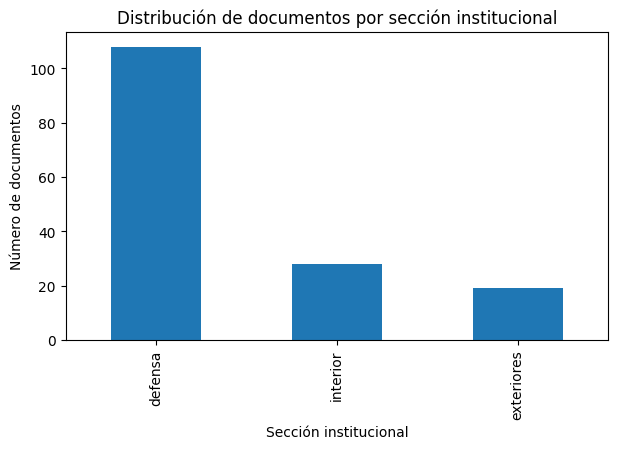

In [4]:
ax = class_distribution.plot(
    kind="bar",
    x=TARGET_COL,
    y="n_documents",
    legend=False,
    figsize=(7, 4),
    title="Distribución de documentos por sección institucional"
)

ax.set_xlabel("Sección institucional")
ax.set_ylabel("Número de documentos")

**Lectura del output.**  
La variable objetivo está claramente desbalanceada. La clase `defensa` concentra 108 de los 155 documentos etiquetados, es decir, el 69,68 % del conjunto. Las clases `interior` y `exteriores` son bastante menores, con 28 y 19 documentos respectivamente.

Esto implica que la accuracy no será suficiente para evaluar el modelo: un clasificador trivial que predijera siempre `defensa` ya obtendría una accuracy cercana al 70 %. Por tanto, será necesario comparar los modelos frente a un baseline de clase mayoritaria y utilizar métricas como macro F1 y matriz de confusión.

### 3.1 Comprobaciones mínimas antes del modelado 

Antes de entrenar modelos textuales, se comprueba que no existan textos vacíos ni etiquetas ausentes dentro del subconjunto etiquetado. Si aparecieran textos vacíos, habría que excluirlos o revisar la extracción, porque TF-IDF no tendría información útil que vectorizar.

In [5]:
text_quality_check = pd.DataFrame({
    "n_missing_text": [df_labeled[TEXT_COL].isna().sum()],
    "n_empty_text": [(df_labeled[TEXT_COL].fillna("").str.strip() == "").sum()],
    "n_missing_target": [df_labeled[TARGET_COL].isna().sum()],
})

text_quality_check

,n_missing_text,n_empty_text,n_missing_target
0,0,0,0


> No hay nulos ni textos vacíos, se puede continuar con la construcción del baseline y los modelos supervisados.

## 4. Exclusión explícita de columnas con riesgo de leakage

Como la variable objetivo es `moncloa_section`, no se deben utilizar como variables predictoras columnas que revelen directa o indirectamente esa etiqueta.

Columnas excluidas por leakage:

- `moncloa_id`
- `moncloa_section`
- `moncloa_subsection`
- `final_match_status`
- `coverage_moncloa`

También se excluyen identificadores o enlaces como `doc_id`, `source_document_id`, `detail_url` y `pdf_url`, ya que no aportan contenido semántico generalizable.

In [6]:
leakage_columns = [
    "moncloa_id",
    "moncloa_section",
    "moncloa_subsection",
    "final_match_status",
    "coverage_moncloa",
]

identifier_columns = [
    "doc_id",
    "source_document_id",
    "detail_url",
    "pdf_url",
]

candidate_excluded_columns = leakage_columns + identifier_columns

available_excluded_columns = [col for col in candidate_excluded_columns if col in df_labeled.columns]

print("Columnas excluidas del conjunto de variables predictoras:")
for col in available_excluded_columns:
    print(f"- {col}")

Columnas excluidas del conjunto de variables predictoras:
- moncloa_id
- moncloa_section
- moncloa_subsection
- final_match_status
- coverage_moncloa
- doc_id
- source_document_id
- detail_url
- pdf_url


**Lectura del output.**  
Se documentan explícitamente qué columnas  no deberían incorporarse en ninguna ampliación del modelo.

Por tanto, esta exclusión actúa como una decisión metodológica explícita: el clasificador debe aprender a partir del contenido textual, no a partir de identificadores, enlaces ni metadatos derivados de La Moncloa.

## 5. Definición de variables del problema

La formulación inicial del problema será:

- `X = text_clean_base`
- `y = moncloa_section`

No se incorporan variables tabulares adicionales en el modelo base. Esta decisión busca evitar que el clasificador aprenda atajos derivados del formato, longitud, calidad OCR, títulos o metadatos institucionales de La Moncloa, en lugar de aprender patrones del contenido textual.

Por tanto, el modelo no pretende maximizar rendimiento a cualquier coste, sino construir una primera solución supervisada conservadora, interpretable y metodológicamente limpia.

In [7]:
X = df_labeled[TEXT_COL].copy()
y = df_labeled[TARGET_COL].copy()

print(f"Número de documentos en X: {len(X)}")
print(f"Número de etiquetas en y: {len(y)}")
print(f"Clases: {sorted(y.unique())}")

X.head()

Número de documentos en X: 155
Número de etiquetas en y: 155
Clases: ['defensa', 'exteriores', 'interior']


0    C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...
1    C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...
2    C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...
3    C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...
4    C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral de la causa 2/81, del Consejo Supremo de Justici...
Name: text_clean_base, dtype: object

## 6. Estrategia de validación

El conjunto etiquetado tiene 155 documentos y tres clases. Como la clase más pequeña tiene pocos ejemplos, una única partición train/test podría dar resultados poco estables.

Por eso se utiliza validación cruzada estratificada con 5 folds. Así se mantiene aproximadamente la proporción de clases en cada partición.

También se usa `Pipeline` para que el TF-IDF se ajuste dentro de cada fold de entrenamiento. Esto evita fuga de información, porque el vectorizador no ve los documentos usados como validación.

Las métricas principales serán:

- `accuracy`, como medida global;
- `balanced_accuracy`, para compensar el desbalance;
- `f1_macro`, como métrica principal porque da el mismo peso a todas las clases.

In [8]:
from sklearn.model_selection import StratifiedKFold

# La clase minoritaria tiene 19 documentos, por lo que 5 folds es viable.
# Cada fold tendrá aproximadamente 3-4 ejemplos de la clase minoritaria.
N_SPLITS = 5
RANDOM_STATE = 42

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

validation_summary = pd.DataFrame({
    "n_documents_labeled": [len(df_labeled)],
    "n_classes": [y.nunique()],
    "min_class_size": [y.value_counts().min()],
    "n_splits": [N_SPLITS],
    "validation_strategy": ["StratifiedKFold"],
})

validation_summary

,n_documents_labeled,n_classes,min_class_size,n_splits,validation_strategy
0,155,3,19,5,StratifiedKFold


## 7. Baseline de clase mayoritaria

Antes de entrenar modelos textuales, se construye un baseline sencillo basado en la clase mayoritaria. Este modelo no aprende del texto: simplemente predice siempre la clase más frecuente del conjunto de entrenamiento.

El objetivo del baseline es establecer una referencia mínima. Dado que la clase `defensa` representa una proporción elevada del conjunto etiquetado, un modelo trivial puede obtener una accuracy aparentemente alta sin clasificar correctamente las clases minoritarias. Por ello, el baseline se evaluará con las mismas métricas que los modelos posteriores: accuracy, balanced accuracy y macro F1. Debido a que:

- `accuracy`: permite medir el porcentaje global de aciertos, pero puede ser optimista en presencia de desbalance.
- `balanced_accuracy`: calcula el rendimiento medio por clase y reduce el efecto de la clase mayoritaria.
- `f1_macro`: calcula la F1 de cada clase y después promedia sin ponderar por frecuencia, por lo que es la métrica principal para comparar modelos en este mini caso.

Este paso permite responder a una pregunta básica: ¿los modelos textuales aportan valor real frente a una regla ingenua basada solo en la distribución de clases?

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

def evaluate_model(model, X, y, cv, model_name):
    # Evalúa un modelo con validación cruzada y devuelve una tabla resumen.
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1
    )

    result = {"model": model_name}

    for metric in SCORING:
        values = scores[f"test_{metric}"]
        result[f"{metric}_mean"] = values.mean()
        result[f"{metric}_std"] = values.std()

    return pd.DataFrame([result])


baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

baseline_results = evaluate_model(
    model=baseline_model,
    X=X,
    y=y,
    cv=cv,
    model_name="Baseline mayoría"
)

baseline_results

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std
0,Baseline mayoría,0.696774,0.015803,0.333333,0.0,0.27373,0.003674


**Lectura del output.**  
El baseline de clase mayoritaria obtiene una accuracy media de 0,697, muy cercana al peso de la clase `defensa` en el conjunto etiquetado. Sin embargo, su balanced accuracy es 0,333 y su macro F1 es 0,274, lo que confirma que no está aprendiendo a distinguir entre clases: simplemente reproduce la clase dominante.

Este resultado justifica no utilizar la accuracy como métrica principal. A partir de este punto, la comparación debe centrarse especialmente en macro F1 y balanced accuracy, porque ambas métricas permiten comprobar si el modelo mejora también sobre `interior` y `exteriores`, no solo sobre `defensa`.

La siguiente decisión lógica es entrenar modelos que sí utilicen el contenido textual del documento mediante TF-IDF.


## 8. Modelo 1: TF-IDF + Logistic Regression

El primer modelo supervisado combina una representación textual mediante TF-IDF con una Regresión Logística multinomial. TF-IDF transforma cada documento en una matriz de términos ponderados según su frecuencia en el documento y su especificidad dentro del corpus.

La Regresión Logística se utiliza como primer modelo porque es interpretable, funciona bien como baseline fuerte en clasificación de texto y permite analizar posteriormente qué términos pesan más en cada clase.

La vectorización TF-IDF se incluye dentro de un `Pipeline` para evitar fuga de información: el vocabulario y los pesos se aprenden únicamente dentro de cada fold de entrenamiento durante la validación cruzada.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90,
        max_features=20_000
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="lbfgs"
    ))
])

logreg_results = evaluate_model(
    model=logreg_pipeline,
    X=X,
    y=y,
    cv=cv,
    model_name="TF-IDF + Logistic Regression"
)

logreg_results

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std
0,TF-IDF + Logistic Regression,0.896774,0.055499,0.844719,0.088969,0.858906,0.0785


**Lectura del output.**  
La Regresión Logística mejora de forma clara el baseline. La accuracy media sube de 0,697 a 0,897, la balanced accuracy pasa de 0,333 a 0,845 y la macro F1 aumenta de 0,274 a 0,859.

La mejora en macro F1 es especialmente relevante porque indica que el modelo no solo aprovecha el predominio de `defensa`, sino que también captura señal textual útil para diferenciar las clases minoritarias. Por tanto, el contenido de `text_clean_base` sí contiene información discriminativa sobre la procedencia institucional.

La siguiente decisión es comparar este modelo con otro clasificador lineal habitual en problemas de texto: Linear SVM.


## 9. Modelo 2: TF-IDF + Linear SVM

El segundo modelo combina la misma representación TF-IDF con un clasificador SVM lineal. Este tipo de modelo suele ser competitivo en problemas de clasificación textual con alta dimensionalidad, porque busca separar las clases mediante hiperplanos lineales en el espacio de términos.

El objetivo no es probar muchos modelos, sino comparar dos enfoques lineales sólidos y defendibles para texto: Regresión Logística y Linear SVM. Ambos se evaluarán con la misma validación cruzada estratificada para que la comparación sea homogénea.

In [11]:
from sklearn.svm import LinearSVC

linear_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90,
        max_features=20_000
    )),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=5000
    ))
])

svm_results = evaluate_model(
    model=linear_svm_pipeline,
    X=X,
    y=y,
    cv=cv,
    model_name="TF-IDF + Linear SVM"
)

svm_results

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std
0,TF-IDF + Linear SVM,0.903226,0.061205,0.831876,0.099643,0.865995,0.083809


**Lectura del output.**  
El modelo TF-IDF + Linear SVM obtiene una accuracy media de 0,903 y una macro F1 de 0,866. Estos valores son ligeramente superiores a los de la Regresión Logística en accuracy y macro F1.

No obstante, la balanced accuracy del Linear SVM es 0,832, algo inferior a la de la Regresión Logística, que era 0,845. Esto indica que ambos modelos tienen un rendimiento muy similar y que la elección no debe interpretarse como una superioridad clara del SVM, sino como una ventaja pequeña según la métrica principal definida.

## 10. Comparación de resultados

Una vez evaluados el baseline y los dos modelos textuales, se comparan sus métricas en una única tabla. Esta comparación permite decidir qué modelo se utilizará para el análisis posterior de matriz de confusión, interpretabilidad, errores y predicción de documentos sin etiqueta.

La métrica principal será `f1_macro`, porque trata todas las clases con el mismo peso y permite detectar si el modelo está ignorando clases minoritarias. Como métricas complementarias se revisarán `balanced_accuracy` y `accuracy`.

In [12]:
results_comparison = pd.concat(
    [
        baseline_results,
        logreg_results,
        svm_results
    ],
    ignore_index=True
)

metric_cols = [
    "accuracy_mean", "accuracy_std",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "f1_macro_mean", "f1_macro_std",
]

results_comparison = results_comparison[
    ["model"] + metric_cols
].sort_values(
    by=["f1_macro_mean", "balanced_accuracy_mean"],
    ascending=False
).reset_index(drop=True)

results_comparison

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std
0,TF-IDF + Linear SVM,0.903226,0.061205,0.831876,0.099643,0.865995,0.083809
1,TF-IDF + Logistic Regression,0.896774,0.055499,0.844719,0.088969,0.858906,0.078500
2,Baseline mayoría,0.696774,0.015803,0.333333,0.000000,0.273730,0.003674


In [13]:
best_model_name = results_comparison.loc[0, "model"]

if best_model_name == "TF-IDF + Logistic Regression":
    best_model = logreg_pipeline
elif best_model_name == "TF-IDF + Linear SVM":
    best_model = linear_svm_pipeline
else:
    best_model = baseline_model

print(f"Mejor modelo según f1_macro_mean: {best_model_name}")

Mejor modelo según f1_macro_mean: TF-IDF + Linear SVM


**Lectura del output.**  
La comparación confirma que los dos modelos basados en TF-IDF superan ampliamente al baseline de clase mayoritaria. El baseline alcanza una macro F1 de 0,274, mientras que la Regresión Logística llega a 0,859 y el Linear SVM a 0,866.

El mejor modelo según macro F1 es `TF-IDF + Linear SVM`. Aun así, la diferencia respecto a la Regresión Logística es pequeña, y la Regresión Logística presenta una balanced accuracy ligeramente superior. Por tanto, la conclusión correcta no es que el SVM gane de forma rotunda, sino que ambos modelos lineales son sólidos y que el SVM se selecciona porque maximiza la métrica principal definida.

La siguiente fase consiste en analizar el comportamiento del Linear SVM con más detalle mediante matriz de confusión, informe por clase, interpretación de términos y revisión de errores.


## 11. Matriz de confusión del mejor modelo

Una vez seleccionado el mejor modelo según la comparación de métricas, se generan predicciones fuera de fold mediante `cross_val_predict`.

Este enfoque permite obtener una predicción para cada documento etiquetado usando únicamente modelos que no han visto ese documento durante el entrenamiento. Con estas predicciones se construyen la matriz de confusión y el informe de clasificación por clase.

La matriz de confusión permitirá comprobar si el modelo mejora de forma equilibrada o si sigue confundiendo especialmente las clases minoritarias.


,pred_defensa,pred_exteriores,pred_interior
real_defensa,105,0,3
real_exteriores,3,16,0
real_interior,9,0,19


,precision,recall,f1-score,support
defensa,0.897436,0.972222,0.933333,108.000000
exteriores,1.000000,0.842105,0.914286,19.000000
interior,0.863636,0.678571,0.760000,28.000000
accuracy,0.903226,0.903226,0.903226,0.903226
macro avg,0.920357,0.830966,0.869206,155.000000
weighted avg,0.903903,0.903226,0.899687,155.000000


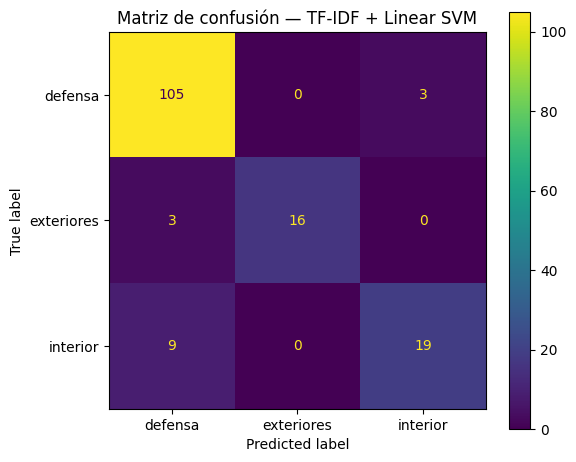

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones fuera de fold con el mejor modelo seleccionado en la comparación.
y_pred_oof = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

labels = sorted(y.unique())

conf_matrix = confusion_matrix(
    y_true=y,
    y_pred=y_pred_oof,
    labels=labels
)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[f"real_{label}" for label in labels],
    columns=[f"pred_{label}" for label in labels]
)

display(conf_matrix_df)

classification_report_dict = classification_report(
    y_true=y,
    y_pred=y_pred_oof,
    labels=labels,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(classification_report_dict).T
display(classification_report_df)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=labels
)
disp.plot(ax=ax, values_format="d")
ax.set_title(f"Matriz de confusión — {best_model_name}")
plt.tight_layout()
plt.show()


**Lectura del output.**  
La matriz de confusión muestra un rendimiento global alto del modelo seleccionado. La clase `defensa` se clasifica correctamente en 105 de 108 documentos, mientras que `exteriores` se clasifica correctamente en 16 de 19 documentos. La clase más problemática es `interior`, con 19 aciertos sobre 28 documentos.

El patrón de errores es informativo: los errores principales se concentran en documentos reales de `interior` clasificados como `defensa` (9 casos). También hay 3 documentos de `exteriores` clasificados como `defensa` y 3 documentos de `defensa` clasificados como `interior`. No se observan confusiones entre `exteriores` e `interior`.

El informe de clasificación refuerza esta lectura. `defensa` obtiene un recall de 0,972, `exteriores` un recall de 0,842 e `interior` un recall de 0,679. Esto indica que el modelo reconoce muy bien la clase dominante y bastante bien `exteriores`, pero tiene más dificultades para recuperar todos los documentos de `interior`.

La siguiente decisión es revisar qué términos está utilizando el modelo para separar las clases y comprobar si las señales aprendidas son interpretables o si están afectadas por ruido documental.


## 12. Interpretabilidad del modelo

Para interpretar el modelo seleccionado, se entrena el pipeline final con todos los documentos etiquetados y se extraen los términos con mayor peso para cada clase.

Esta interpretación debe entenderse como una aproximación al vocabulario que ayuda al modelo a distinguir las secciones institucionales. No equivale a una explicación histórica completa, pero permite comprobar si el clasificador se apoya en términos razonables o en señales poco interpretables.


In [15]:
from sklearn.base import clone

# Entrenamos el modelo final con todos los documentos etiquetados.
final_model = clone(best_model)
final_model.fit(X, y)

vectorizer = final_model.named_steps["tfidf"]
classifier = final_model.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = classifier.coef_
classes = classifier.classes_

top_terms_rows = []

for class_idx, class_label in enumerate(classes):
    class_coefs = coefs[class_idx]
    top_indices = np.argsort(class_coefs)[-15:][::-1]

    for rank, feature_idx in enumerate(top_indices, start=1):
        top_terms_rows.append({
            "class": class_label,
            "rank": rank,
            "term": feature_names[feature_idx],
            "coefficient": class_coefs[feature_idx],
        })

top_terms_by_class = pd.DataFrame(top_terms_rows)

top_terms_by_class

,class,rank,term,coefficient
0,defensa,1,sr,0.542392
1,defensa,2,general,0.445928
2,defensa,3,justicia,0.397636
3,defensa,4,capitan,0.372972
4,defensa,5,de justicia,0.369661
5,defensa,6,causa,0.347020
6,defensa,7,defensa,0.339533
7,defensa,8,procesados,0.322250
8,defensa,9,cesid,0.321451
9,defensa,10,ref,0.316314


**Lectura del output.**  
Los términos más relevantes por clase muestran que el modelo combina señales semánticas útiles con cierto ruido procedente del OCR, el formato documental y expresiones administrativas.

En `defensa`, aparecen términos coherentes con el dominio militar y judicial, como `general`, `justicia`, `capitan`, `causa`, `defensa`, `procesados`, `cesid` o `de defensa`. Esto sugiere que el modelo está capturando parte del vocabulario propio de documentación militar, judicial o vinculada al Ministerio de Defensa.

En `exteriores`, aparecen términos como `españa`, `de asuntos`, `exteriores`, `asuntos exteriores` o `asuntos`, que son coherentes con documentación diplomática. Sin embargo, también aparecen términos como `the` o `mr`, que probablemente reflejan documentos con contenido en inglés o fórmulas diplomáticas. Esto no invalida el modelo, pero indica que parte de la señal procede del estilo documental.

En `interior`, la interpretación es más débil. El término con mayor peso, `golpe`, sí es semánticamente relevante, y también aparecen señales interpretables como `madrid`, `implicados` o `comandancia`. Sin embargo, buena parte de los términos más influyentes son poco informativos o ruidosos: `efe`, `inf`, `__________`, `si`, `un`, `se`, `yo`, `redacted` o códigos numéricos.

Esto ayuda a explicar por qué `interior` es la clase con menor recall. El modelo parece apoyarse en una mezcla de señales semánticas reales y patrones de formato/OCR, lo que reduce la limpieza interpretativa de esta clase y puede hacerla más vulnerable a confusiones con `defensa`.

Por tanto, la interpretación de coeficientes es útil para auditar el modelo, pero también revela una limitación clara: una limpieza específica de ruido textual o una lista de stopwords adaptada al corpus podría mejorar la interpretabilidad.

La siguiente fase es revisar los documentos mal clasificados para comprobar si los errores responden a ambigüedad temática, solapamiento institucional o ruido textual.


## 13. Análisis de errores

Tras evaluar el modelo mediante predicciones fuera de fold, se identifican los documentos mal clasificados. El objetivo de este bloque no es solo contar errores, sino revisar qué tipos de documentos generan confusión entre secciones institucionales.

Este análisis ayuda a valorar si los errores son razonables por ambigüedad documental, por solapamiento temático entre instituciones, por ruido OCR o por limitaciones del tamaño muestral.


In [16]:
df_error_analysis = df_labeled.copy()
df_error_analysis["y_true"] = y.values
df_error_analysis["y_pred_oof"] = y_pred_oof
df_error_analysis["is_error"] = df_error_analysis["y_true"] != df_error_analysis["y_pred_oof"]

error_summary = (
    df_error_analysis
    .groupby(["y_true", "y_pred_oof"])
    .size()
    .reset_index(name="n_documents")
    .sort_values(["y_true", "n_documents"], ascending=[True, False])
)

display(error_summary)

errors_df = df_error_analysis[df_error_analysis["is_error"]].copy()

errors_df["text_excerpt"] = (
    errors_df[TEXT_COL]
    .fillna("")
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 500)
)

error_columns = [
    "doc_id",
    "title",
    "y_true",
    "y_pred_oof",
    "text_clean_length_words",
    "text_excerpt",
]

errors_for_review = (
    errors_df[error_columns]
    .sort_values(["y_true", "y_pred_oof", "doc_id"])
)

print(f"Número total de errores fuera de fold: {len(errors_for_review)}")

errors_for_review

,y_true,y_pred_oof,n_documents
0,defensa,defensa,105
1,defensa,interior,3
3,exteriores,exteriores,16
2,exteriores,defensa,3
5,interior,interior,19
4,interior,defensa,9


Número total de errores fuera de fold: 15


,doc_id,title,y_true,y_pred_oof,text_clean_length_words,text_excerpt
157,rtve_1703,Semestral de la amenaza interior (10 de febrero de 1981; 9 de marzo de 1981).,defensa,interior,8714,MINISTERIO DE DEFENSA CENTRO SUPERIOR DE INFORMACION DE LA DEFENSA # MICROFILMACION 03838/S | S/Ref. | Núm. | Fech...
69,rtve_1791,"""Guión que sirvió de base para la reunión de S.M. el Rey con el Presidente del Gobierno",defensa,interior,1363,"PERSONAL Y RESERVADA CASA DE S. M. EL REY EL SECRETARIO GENERAL Palacio de la Zarzuela, 14 de Diciembre de 1981 I..."
56,rtve_1804,Nota al PREJUJEM (Presidente de la Junta de Jefes de Estado Mayor). Algunos datos para una crónica de un golpe anunc...,defensa,interior,2657,"1 # NOTA PREJUJEN 1. Existe una campaña propagandística para confundir a los cuadros de Mandos del Ejército, un mo..."
101,rtve_1759,D.15._AGMAE_R40201_Exp._215,exteriores,defensa,367,S. R. Página 23/Mar20 1981 # CÂMARA MUNICIPAL DE ELVAS TELEFS.: 22264-22267 APARTADO 70 7351 ELVAS CODEX Exmo Sen...
97,rtve_1763,D.19._AGA-83-07633_exp._4,exteriores,defensa,579,725.101 Citaso esta referencia en la contestación 441323.2(46)-1/9 Embajada de España NO 507 IBEROAMERICA 18 MAYO...
90,rtve_1770,D.25._AGA-83-08764_exp._5,exteriores,defensa,445,"729.1 66' 333.3 (46)-1/9 Cifase esta referencia en la contestación Embajada de España La Habana, 7 de abril de 198..."
162,rtve_1698,Documento manuscrito de posible planificación del golpe.,interior,defensa,469,"""Antes de 20 no se dispondría de la adecuada valoración de unidades"". - Datos actualizados cada 7 días a partir 17-..."
160,rtve_1700,Nota del EM de la Guardia Civil con una secuencia parcial de los hechos del asalto al Congreso.,interior,defensa,1108,"DIRECCION GENERAL DE LA GUARDIA CIVIL ESTADO MAYOR - 2a SECCION. 18,20 Noticias dadas por radio sobre asunto CORTE..."
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª sección EM el día 23-F informando del estado de situación (23 de febr...,interior,defensa,19857,SERVICIO RADIOTELEGRAFICO DE LA GUARDIA CIVIL Radio n.°: 23 FEB 1981 P. P. 10/10 EL OPERADOR TELEX NUMERO 191 LER...
148,rtve_1712,Oficio zona País Vasco que expresa una comunicación del teniente coronel Tejero sobre la posible situación de tensió...,interior,defensa,476,DIRECCION GENERAL DE LA GUARDIA CIVIL S. ZONA JEFATURA S/Rf.a Núm. Fecha N/Rf.a JAP/jso. Núm. 543 # RESERVADO ASU...


**Lectura del output.**  
El modelo comete 15 errores sobre 155 documentos etiquetados. La mayoría de errores se concentran en documentos reales de `interior` clasificados como `defensa` (9 casos). Este patrón es coherente con la matriz de confusión y sugiere que parte de los documentos de Interior contiene vocabulario militar, judicial o relacionado con el golpe que el modelo asocia con Defensa.

Los errores concretos refuerzan esta interpretación. Entre los documentos de `interior` clasificados como `defensa` aparecen textos sobre Guardia Civil, Tejero, FAS, juicio del 23-F, planificación del golpe o notas sobre involucionismo político. Aunque institucionalmente estén etiquetados como `interior`, su vocabulario se solapa mucho con el campo militar y judicial.

Los 3 errores de `exteriores` clasificados como `defensa` corresponden a documentos breves de carácter diplomático o administrativo. En documentos cortos, el modelo dispone de menos contexto textual y puede apoyarse en señales débiles o ambiguas.

Los 3 errores de `defensa` clasificados como `interior` también muestran que existen documentos de Defensa con contenido relacionado con amenaza interior, orden público o contexto político. Por tanto, los errores no parecen aleatorios: responden al solapamiento real entre categorías institucionales y al tamaño limitado del corpus.

La conclusión no es que el modelo “se equivoque sin sentido”, sino que algunas etiquetas institucionales agrupan documentos cuyo vocabulario se cruza con el de otra sección. En particular, `interior` parece una clase más heterogénea y menos separable que `defensa` o `exteriores`.

La siguiente decisión es aplicar el modelo final a los 12 documentos sin etiqueta institucional, manteniendo la predicción como propuesta automática y no como verdad validada.


## 14. Predicción de documentos sin etiqueta institucional

Después de evaluar el modelo sobre los documentos etiquetados, se entrena el modelo final con los 155 documentos que tienen `moncloa_section` disponible y se aplica sobre los 12 documentos sin etiqueta institucional.

Estas predicciones no deben interpretarse como verdad documental, sino como una propuesta automática de clasificación. Su utilidad principal es exploratoria: ayuda a priorizar una posible revisión manual de los documentos sin correspondencia institucional trazable.


In [17]:
X_unlabeled = df_unlabeled[TEXT_COL].fillna("").copy()

unlabeled_pred = final_model.predict(X_unlabeled)
decision_scores = final_model.decision_function(X_unlabeled)

score_columns = [
    f"score_{class_label}"
    for class_label in final_model.named_steps["clf"].classes_
]

scores_df = pd.DataFrame(
    decision_scores,
    columns=score_columns
)

unlabeled_predictions = df_unlabeled[
    ["doc_id", "title", "pdf_url", "text_clean_length_words"]
].reset_index(drop=True)

unlabeled_predictions["predicted_moncloa_section"] = unlabeled_pred

unlabeled_predictions = pd.concat(
    [unlabeled_predictions, scores_df],
    axis=1
)

unlabeled_predictions = unlabeled_predictions.sort_values(
    by="predicted_moncloa_section"
).reset_index(drop=True)

unlabeled_predictions

,doc_id,title,pdf_url,text_clean_length_words,predicted_moncloa_section,score_defensa,score_exteriores,score_interior
0,rtve_1761,D.17._AGMAE_R40201_Exp._215,https://www.rtve.es/contenidos/documentos/23f-desclasificado/154_2026_d17_agmae_r40201_exp_215.pdf,169,exteriores,-0.592423,0.430128,-0.617980
1,rtve_1760,D.16._AGMAE_R40201_Exp._215,https://www.rtve.es/contenidos/documentos/23f-desclasificado/153_2026_d16_agmae_r40201_exp_215.pdf,182,exteriores,-0.467886,0.245600,-0.592099
2,rtve_1757,D.13._AGMAE_R39017_Exp._4,https://www.rtve.es/contenidos/documentos/23f-desclasificado/150_2026_d13_agmae_r39017_exp_4.pdf,78,exteriores,-0.293978,0.080921,-0.712735
3,rtve_1755,D.12._AGMAE_R39017_Exp._4,https://www.rtve.es/contenidos/documentos/23f-desclasificado/149_2026_d12_agmae_r39017_exp_4.pdf,113,exteriores,-0.605565,0.441295,-0.705391
4,rtve_1754,D.11._AGMAE_R39017_Exp._4,https://www.rtve.es/contenidos/documentos/23f-desclasificado/148_2026_d11_agmae_r39017_exp_4.pdf,114,exteriores,-0.411750,0.088621,-0.577165
5,rtve_1753,D.10._AGMAE_R39017_Exp._4,https://www.rtve.es/contenidos/documentos/23f-desclasificado/147_2026_d10_agmae_r39017_exp_4.pdf,196,exteriores,-0.580757,0.493501,-0.805391
6,rtve_1752,D.9._AGMAE_R39017_Exp._4,https://www.rtve.es/contenidos/documentos/23f-desclasificado/146_2026_d9_agmae_r39017_exp_4.pdf,87,exteriores,-0.367646,0.110125,-0.639436
7,rtve_1750,D.7._AGMAE_R39017_Exp._4,https://www.rtve.es/contenidos/documentos/23f-desclasificado/144_2026_d7_agmae_r39017_exp_4.pdf,146,exteriores,-0.713466,0.731240,-0.910454
8,rtve_1749,D.6._AGMAE_R39017_Exp. 4,https://www.rtve.es/contenidos/documentos/23f-desclasificado/143_2026_d6_agmae_r39017_exp_4.pdf,134,exteriores,-0.710275,0.737485,-0.923252
9,rtve_1748,D.5._AGMAE_R39017_Exp._4,https://www.rtve.es/contenidos/documentos/23f-desclasificado/142_2026_d5_agmae_r39017_exp_4.pdf,184,exteriores,-0.757598,0.811612,-0.958082


**Lectura del output.**  
Los 12 documentos sin etiqueta institucional son clasificados por el modelo como `exteriores`. Esta predicción es coherente con los títulos observados, ya que varios documentos siguen patrones asociados a documentación diplomática o administrativa.

Como el modelo seleccionado es un Linear SVM, los valores `score_*` no son probabilidades. Son puntuaciones internas del modelo: cuanto mayor es el score de una clase respecto al resto, más clara es la decisión para ese documento.

Por tanto, estas predicciones deben interpretarse como una ayuda exploratoria y no como una etiqueta definitiva. Servirían para priorizar una revisión manual posterior.

## 15. Guardado de resultados

Finalmente, se guardan las tablas y figuras principales generadas por el mini caso. Estos archivos permiten reutilizar los resultados en el informe final, en el notebook principal de integración y en la revisión posterior del proyecto.

Los outputs se guardan en carpetas relativas del proyecto para mantener la reproducibilidad.


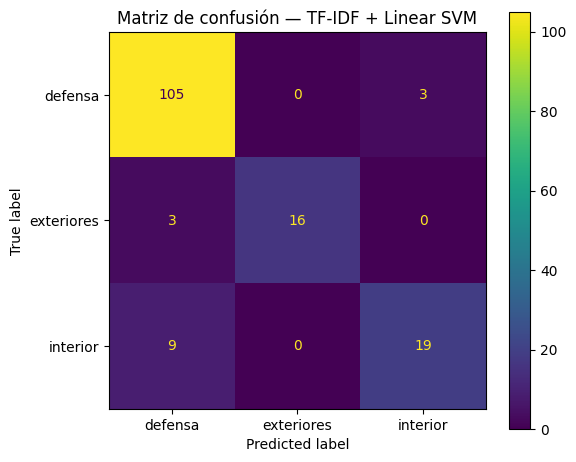

,output_type,path
0,table,outputs/tables/caso1_clasificacion_model_metrics.csv
1,table,outputs/tables/caso1_clasificacion_report_best_model.csv
2,table,outputs/tables/caso1_clasificacion_confusion_matrix.csv
3,table,outputs/tables/caso1_clasificacion_top_terms_by_class.csv
4,table,outputs/tables/caso1_clasificacion_errors_for_review.csv
5,table,outputs/tables/caso1_clasificacion_unlabeled_predictions.csv
6,figure,outputs/figures/caso1_clasificacion_confusion_matrix.png


In [19]:
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

results_comparison.to_csv(
    OUTPUT_TABLES_DIR / "caso1_clasificacion_model_metrics.csv",
    index=False
)

classification_report_df.to_csv(
    OUTPUT_TABLES_DIR / "caso1_clasificacion_report_best_model.csv"
)

conf_matrix_df.to_csv(
    OUTPUT_TABLES_DIR / "caso1_clasificacion_confusion_matrix.csv"
)

top_terms_by_class.to_csv(
    OUTPUT_TABLES_DIR / "caso1_clasificacion_top_terms_by_class.csv",
    index=False
)

errors_for_review.to_csv(
    OUTPUT_TABLES_DIR / "caso1_clasificacion_errors_for_review.csv",
    index=False
)

unlabeled_predictions.to_csv(
    OUTPUT_TABLES_DIR / "caso1_clasificacion_unlabeled_predictions.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=labels
)
disp.plot(ax=ax, values_format="d")
ax.set_title(f"Matriz de confusión — {best_model_name}")
plt.tight_layout()

confusion_matrix_path = OUTPUT_FIGURES_DIR / "caso1_clasificacion_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

saved_outputs = pd.DataFrame({
    "output_type": [
        "table",
        "table",
        "table",
        "table",
        "table",
        "table",
        "figure",
    ],
    "path": [
        OUTPUT_TABLES_DIR / "caso1_clasificacion_model_metrics.csv",
        OUTPUT_TABLES_DIR / "caso1_clasificacion_report_best_model.csv",
        OUTPUT_TABLES_DIR / "caso1_clasificacion_confusion_matrix.csv",
        OUTPUT_TABLES_DIR / "caso1_clasificacion_top_terms_by_class.csv",
        OUTPUT_TABLES_DIR / "caso1_clasificacion_errors_for_review.csv",
        OUTPUT_TABLES_DIR / "caso1_clasificacion_unlabeled_predictions.csv",
        confusion_matrix_path,
    ],
})

saved_outputs["path"] = saved_outputs["path"].apply(
    lambda p: str(Path(p).relative_to(PROJECT_ROOT))
)

saved_outputs

**Lectura del output.**  
Se guardan las tablas principales del mini caso y la figura de la matriz de confusión en las carpetas `outputs/tables/` y `outputs/figures/`.

Estos archivos permiten reutilizar los resultados en el informe final o en una presentación. No se guarda el modelo entrenado, ya que en este mini caso el objetivo principal es analizar la viabilidad de la clasificación y no desplegar un clasificador final.

## 16. Conclusiones finales

El mini caso demuestra que es viable clasificar automáticamente documentos del corpus RTVE 23-F por procedencia institucional utilizando únicamente el texto limpio `text_clean_base` como variable predictora y `moncloa_section` como variable objetivo.

La primera conclusión es que el baseline de clase mayoritaria no es suficiente. Aunque alcanza una accuracy cercana al 70 %, su balanced accuracy y su macro F1 son muy bajas porque predice sistemáticamente la clase dominante. Esto confirma que el desbalance del target obliga a evaluar con métricas que tengan en cuenta el comportamiento por clase, especialmente macro F1.

La segunda conclusión es que los modelos textuales sí aportan valor. Tanto la Regresión Logística como el Linear SVM superan ampliamente al baseline en accuracy, balanced accuracy y macro F1. El mejor modelo según la métrica principal definida es `TF-IDF + Linear SVM`, con una macro F1 media aproximada de 0,866 en validación cruzada estratificada. No obstante, la diferencia frente a la Regresión Logística es pequeña, por lo que ambos modelos pueden considerarse soluciones lineales sólidas.

La tercera conclusión es que el modelo no falla de forma aleatoria. La mayor dificultad aparece en la clase `interior`, especialmente en documentos que el modelo clasifica como `defensa`. La revisión de errores sugiere que esta confusión se debe al solapamiento semántico entre documentos de Interior y Defensa: algunos textos de Interior contienen vocabulario relacionado con Guardia Civil, Tejero, juicio, golpe, causa, FAS o justicia militar.

La cuarta conclusión es que la interpretabilidad del modelo es útil, pero también revela limitaciones. En `defensa` y `exteriores` aparecen términos relativamente coherentes con el dominio militar, judicial o diplomático. En cambio, la clase `interior` combina algunos términos informativos, como `golpe`, `madrid`, `implicados` o `comandancia`, con señales ruidosas como partículas frecuentes, marcas OCR, números o expresiones poco interpretables. Esto puede contribuir a explicar su menor recall.

Como aplicación práctica, el modelo predice los 12 documentos sin etiqueta institucional como `exteriores`. Esta salida es coherente con sus títulos y referencias documentales, especialmente por la presencia de patrones asociados a documentación del Ministerio de Asuntos Exteriores. Aun así, estas predicciones deben entenderse como una propuesta automática para revisión manual, no como etiquetas validadas.

Las principales limitaciones del mini caso son el tamaño reducido del corpus etiquetado, el desbalance entre clases, el ruido OCR, la presencia de términos poco informativos en la representación TF-IDF y el solapamiento real entre categorías institucionales. Como extensiones opcionales, no necesarias para validar este mini caso, podrían explorarse una limpieza específica de ruido textual, una lista de stopwords adaptada al corpus, una comparación controlada con `title + text_clean_base` y una revisión manual de los documentos sin etiqueta. Estas extensiones no invalidan el resultado actual: servirían para comprobar si es posible mejorar la interpretabilidad o refinar las predicciones, pero el modelo presentado ya constituye una solución supervisada completa, evaluada y trazable.